In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
time = np.arange(100)
sales = 10 + 0.5 * time + 10 * np.sin(2 * np.pi * time / 7) + np.random.randn(100)
df = pd.DataFrame({'date': dates, 'sales': sales})

In [3]:
df.head()

,date,sales
0,2023-01-01,8.819956
1,2023-01-02,18.025580
2,2023-01-03,22.823239
3,2023-01-04,15.794764
4,2023-01-05,6.030105


In [4]:
data = df[['sales']]

In [5]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
data = sc.fit_transform(data)

In [6]:
X, y = [], []
seq_len = 10
for i in range(seq_len, len(data)):
  X.append(data[i-seq_len:i])
  y.append(data[i])
X = np.array(X)
y = np.array(y)

In [7]:
split = int(0.8*len(X))
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

In [10]:
from keras.models import Sequential
from keras.layers import LSTM, Dense
model = Sequential()
model.add(LSTM(50, input_shape = (seq_len, 1)))
model.add(Dense(1))
# LSTM(50): 50 neurons to learn different patterns (trends/cycles).
# input_shape(10, 1): Uses 10 past days (steps) of 1 variable (sales) as input.
# Dense(1): Condenses the LSTM's memory into a single predicted value.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(loss='mean_squared_error', optimizer='adam')

In [14]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

In [15]:
history = model.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 200, batch_size = 32, verbose = 1, callbacks = [early_stopping])

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0180 - val_loss: 0.0146
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0159 - val_loss: 0.0198
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0155 - val_loss: 0.0255
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0161 - val_loss: 0.0288
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0163 - val_loss: 0.0270
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0160 - val_loss: 0.0224
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0152 - val_loss: 0.0187
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0150 - val_loss: 0.0158
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0150 - val_loss: 0.0145
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0151 - val_loss: 0.0142
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0150 - val_loss: 0.0147
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0146 - val_lo

In [16]:
print("Training loss: ", history.history['loss'][-1])
print("Validation loss: ", history.history['val_loss'][-1])

Training loss:  0.0007263260777108371
Validation loss:  0.0022747202310711145


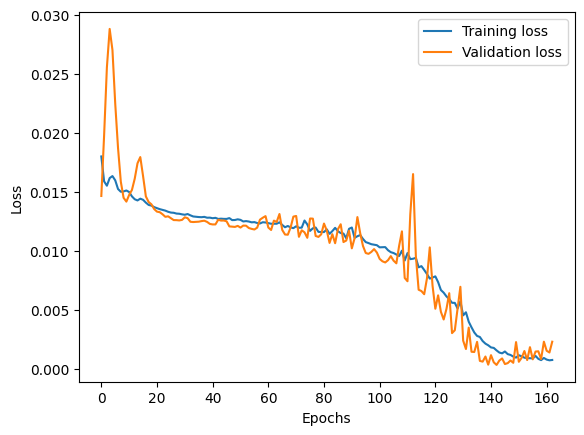

In [17]:
plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


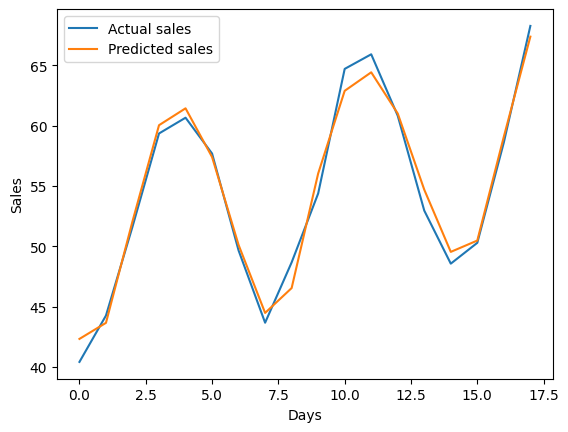

In [18]:
y_pred = model.predict(X_test)
y_pred = sc.inverse_transform(y_pred)
y_test = sc.inverse_transform(y_test)
plt.plot(y_test, label = 'Actual sales')
plt.plot(y_pred, label = 'Predicted sales')
plt.xlabel('Days')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [19]:
next_day_pred = data[-10:]
next_day_pred = np.expand_dims(next_day_pred, axis = 0)
next_day_pred = model.predict(next_day_pred)
next_day_pred = sc.inverse_transform(next_day_pred)
print("Predicted sales for the next day: ", next_day_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Predicted sales for the next day:  [[69.12456]]
